In [ ]:
#Import needed Packages


#Data Analysis
import json
import pandas as pd

#Setting
# Increase the maximum number of characters displayed in each column
pd.options.display.max_colwidth = 1000
pd.options.display.max_rows
pd.options.display.max_columns

20

## **Arabic Propaganda Detection Problem**


### Arabic Propaganda Detection Workflow Steps:
In general, The competition solution workflow goes through six stages described in the [Data Science Solutions book](https://leanpub.com/data-science-solutions).

* Problem Definition.
* Acquire training and testing data.
* Analyze, identify patterns, and explore the data.
* Data cleansing
* Model, predict and solve the problem.
* Results discussion and report.

Overall , the workflow indicates a general sequence of how each stage may follow the other. However, there are use cases with exceptions.

## 1. Problem Statement

The analysis of Arabic propaganda text using machine learning or deep learning is not an easy task, as the characteristic of Arabic propaganda differ from that of other languages texts. In this  task, a EDA of  Arabic ppropaganda text is presented.

## 2. Loading the Dataset
The dataset contains around 930 sample of news tweets that extend from top-2 news sources from each Arab country. This dataset consist of 17 features (techniques) beside (no-technique)  and 930 instance. In addition,it divided into train, dev, Dev-Test and test where each contains 504,52,51 and 323 tweets respectively.

The total number of tokens and char for training set was 7949 and 56731, respictivally. Moreover, the dataset is available in [2022 Shared Task on Propaganda Detection in Arabic]( https://gitlab.com/arabic-nlp/propaganda-detection/-/blob/main/README.md). The following task will be performed in this section:



* Load the training dataset for both task 1 and 2
* Find the total number of tokens and characters



In [ ]:


# Open the file
with open('/content/task1_train.json') as file:
    # Load the JSON data from the file
    data = json.load(file)

# Use the data as a dictionary
print(data)

[{'id': '1358824915483435012', 'text': '#بي_بي_سي_ترندينغ: النساء "تثرثر كثيرا" رئيس أولمبياد #طوكيو يتعرض لضغوط للاستقالة بعد تصريحه المثير للجدل https://t.co/Ywtth34LqF', 'labels': ['no technique']}, {'id': '1389927866356412416', 'text': '"ده مش معتقل ده أحسن من اللوكاندة".. جدل وسخرية من زيارات تنظمها وزارة الداخلية للسجون #مصر https://t.co/VkkCrRjOCF', 'labels': ['Smears', 'Exaggeration/Minimisation']}, {'id': '1364082975428677632', 'text': 'الرجل الذي كان من\xa0فراغ https://t.co/2bnHiRqGRQ', 'labels': ['no technique']}, {'id': '1391667689656102914', 'text': 'RT @AJABreaking: عاجل | حركة حماس: ما يجري في المسجد الأقصى مجزرة حقيقية ستدفع سلطات الاحتلال الإسرائيلية ثمنها', 'labels': ['Loaded Language', 'Appeal to fear/prejudice', 'Name calling/Labeling']}, {'id': '1389360446440972289', 'text': 'انطلاق أسبوع المرور العربي تحت شعار: "الحوادث ليست بمصير بل إهمال وتقصير".', 'labels': ['Slogans']}, {'id': '1378256980297539584', 'text': 'مراسل بي بي سي في الصين: "الواقع المروع للعمل الصحفي

In [ ]:
# Split the sentences in the column into tokens
df1['tokens'] = df1['text'].str.split()

# Count the total number of tokens
total_tokens = df1['tokens'].apply(len).sum()

# Print the result
print("Total number of tokens:", total_tokens)

Total number of tokens: 7949


In [ ]:
# count total number of characters in the column
df1['column_char_count'] = df1['text'].apply(lambda x: len(str(x)))

# Count the total number of tokens
total_char = df1['column_char_count'].sum()


# Print the result
print("Total number of char:", total_char)

# # display result
# print(df1)

Total number of char: 56731


## 3. Exploratory Data Analysis (EDA) and Pre-Processing




**Data Inspection**
* What data type is data?
* How many tweets does dataset contain?
* Inspect the first data point, what does it look like?
* How many tweets of each category does dataset contain?


So, I tried to analyze by describing the data (Take a look into the dataset to understand it).In the following sections, I tried to answer several questions that help me to understand the dataset.



In [ ]:
#viewing the data
print(df1.head(3))

                    id  \
0  1358824915483435008   
1  1389927866356412416   
2  1364082975428677632   

                                                                                                                                 text  \
0  #بي_بي_سي_ترندينغ: النساء "تثرثر كثيرا" رئيس أولمبياد #طوكيو يتعرض لضغوط للاستقالة بعد تصريحه المثير للجدل https://t.co/Ywtth34LqF   
1                 "ده مش معتقل ده أحسن من اللوكاندة".. جدل وسخرية من زيارات تنظمها وزارة الداخلية للسجون #مصر https://t.co/VkkCrRjOCF   
2                                                                                      الرجل الذي كان من فراغ https://t.co/2bnHiRqGRQ   

                                labels  \
0                       [no technique]   
1  [Smears, Exaggeration/Minimisation]   
2                       [no technique]   

                                                                                                                                               tokens  \
0  [#بي_بي_سي_ترندينغ:, 

### 3.1 Which features are available in the dataset?



In [ ]:
print(df1.columns.values, df2.columns.values)

['id' 'text' 'labels'] ['id' 'text' 'labels']


In [ ]:
print(df1.loc[1])

id                                                                                                        1389927866356412416
text      "ده مش معتقل ده أحسن من اللوكاندة".. جدل وسخرية من زيارات تنظمها وزارة الداخلية للسجون #مصر https://t.co/VkkCrRjOCF
labels                                                                                    [Smears, Exaggeration/Minimisation]
Name: 1, dtype: object


In [ ]:
print(df2.loc[1])

id                                                                                                                                                                                                                  1389927866356412416
text                                                                                                                "ده مش معتقل ده أحسن من اللوكاندة".. جدل وسخرية من زيارات تنظمها وزارة الداخلية للسجون #مصر https://t.co/VkkCrRjOCF
labels    [{'start': 1, 'end': 33, 'technique': 'Exaggeration/Minimisation', 'text': 'ده مش معتقل ده أحسن من اللوكاندة'}, {'start': 37, 'end': 86, 'technique': 'Smears', 'text': 'جدل وسخرية من زيارات تنظمها وزارة الداخلية للسجون'}]
Name: 1, dtype: object


In [ ]:
print(df2.loc[1])

id                                                                                                                                                                                                                  1389927866356412416
text                                                                                                                "ده مش معتقل ده أحسن من اللوكاندة".. جدل وسخرية من زيارات تنظمها وزارة الداخلية للسجون #مصر https://t.co/VkkCrRjOCF
labels    [{'start': 1, 'end': 33, 'technique': 'Exaggeration/Minimisation', 'text': 'ده مش معتقل ده أحسن من اللوكاندة'}, {'start': 37, 'end': 86, 'technique': 'Smears', 'text': 'جدل وسخرية من زيارات تنظمها وزارة الداخلية للسجون'}]
Name: 1, dtype: object


### 3.2 Which is the data type of each feature?



In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      504 non-null    int64 
 1   text    504 non-null    object
 2   labels  504 non-null    object
dtypes: int64(1), object(2)
memory usage: 11.9+ KB


    From the above results, we observed that:

    - Object: text and labels

    - Numerical: id
Besides, this helps to select the appropriate plots for visualization

### 3.3 What is the distribution of categorical features?
(Statistics summary on the dataset)

In [ ]:
df1.describe(include=['O'])

,text,labels
count,504,504
unique,504,101
top,"#بي_بي_سي_ترندينغ: النساء ""تثرثر كثيرا"" رئيس أولمبياد #طوكيو يتعرض لضغوط للاستقالة بعد تصريحه المثير للجدل https://t.co/Ywtth34LqF",[no technique]
freq,1,95


We can observed that:

* Text are unique across the dataset (count=unique=504).
* 'no technique' is the most popular labels. Howevere, it's based on concatonation list that is not taken into considration. Actually it is about 10.8%


In [ ]:
# Flatten the "labels" column into a single list of strings
flattened = df1["labels"].explode()

# Count the number of instances of "Repetition" in the "label" column
count = (flattened == "no technique").sum()
print("Number of instances of 'no technique' in the 'labels' column:", count)

Number of instances of 'no technique' in the 'labels' column: 95


In [ ]:
# Define a function to check if the text is in a list
def check_list_for_text(list_of_texts, text):
    return text in list_of_texts

# Use the apply method to apply the function to each row of the "labels" column
filtered_df = df1[df1["labels"].apply(lambda x: check_list_for_text(x, "no technique"))]

# Print the filtered DataFrame
print(filtered_df)

                      id  \
0    1358824915483435008   
2    1364082975428677632   
19   1325345970981318656   
22   1384110098289594368   
24   1374002150620213248   
..                   ...   
438  1372699741289611264   
439  1372295109983735808   
451  1389776866681114624   
452  1400059625441988608   
457  1393100013341863936   

                                                                                                                                                                           text  \
0                                            #بي_بي_سي_ترندينغ: النساء "تثرثر كثيرا" رئيس أولمبياد #طوكيو يتعرض لضغوط للاستقالة بعد تصريحه المثير للجدل https://t.co/Ywtth34LqF   
2                                                                                                                                الرجل الذي كان من فراغ https://t.co/2bnHiRqGRQ   
19                                                                  🎥 #قهوة_الصباح | قصيدة في حب الوطن | نوف بنت خلفان البريكي

### 3.4 Is there any null or unknown values (Missing value)?

In [ ]:
print('The total and percentages of null values per feature:\n')
missing_data = pd.DataFrame({'Total_Missing': df1.isnull().sum(), '%_Missing': (df1.isnull().sum()/504)*100})
missing_data
## The data is clean, there is no null values in the dataset

The total and percentages of null values per feature:



,Total_Missing,%_Missing
id,0,0.0
text,0,0.0
labels,0,0.0


### Visualization



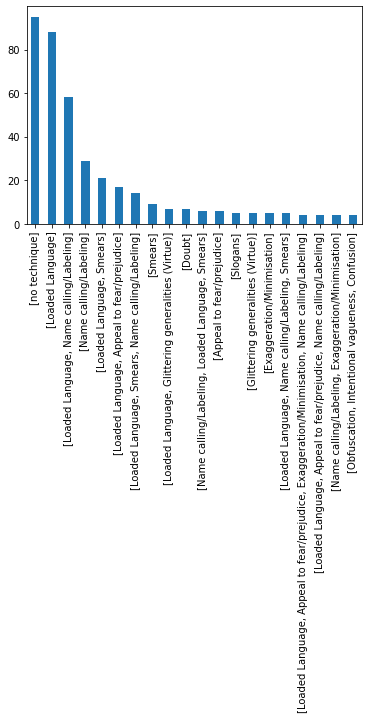

In [ ]:
df1.labels.value_counts()[:20].plot(kind='bar');

# The dataset comes with 26 labels.The label indicates the poet origin.

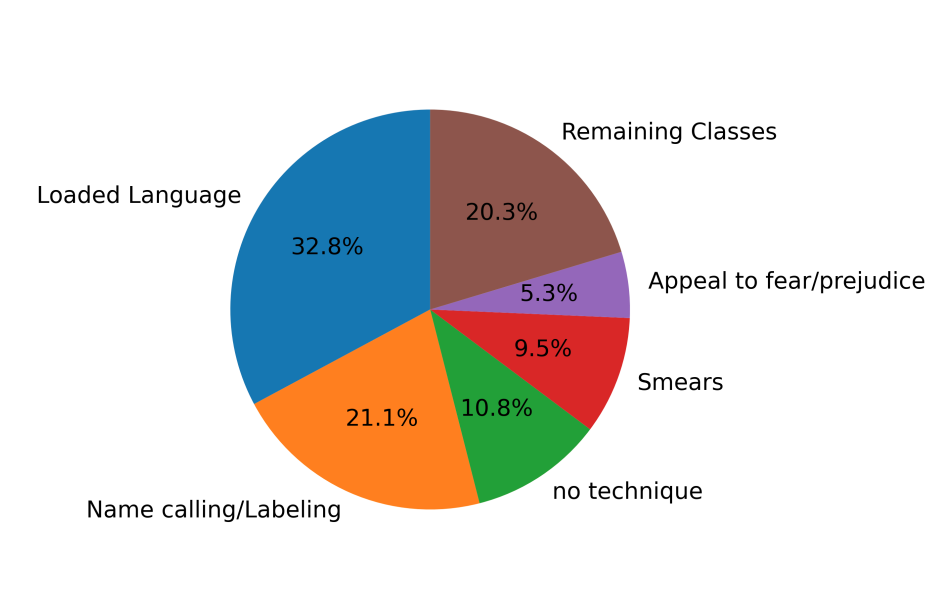

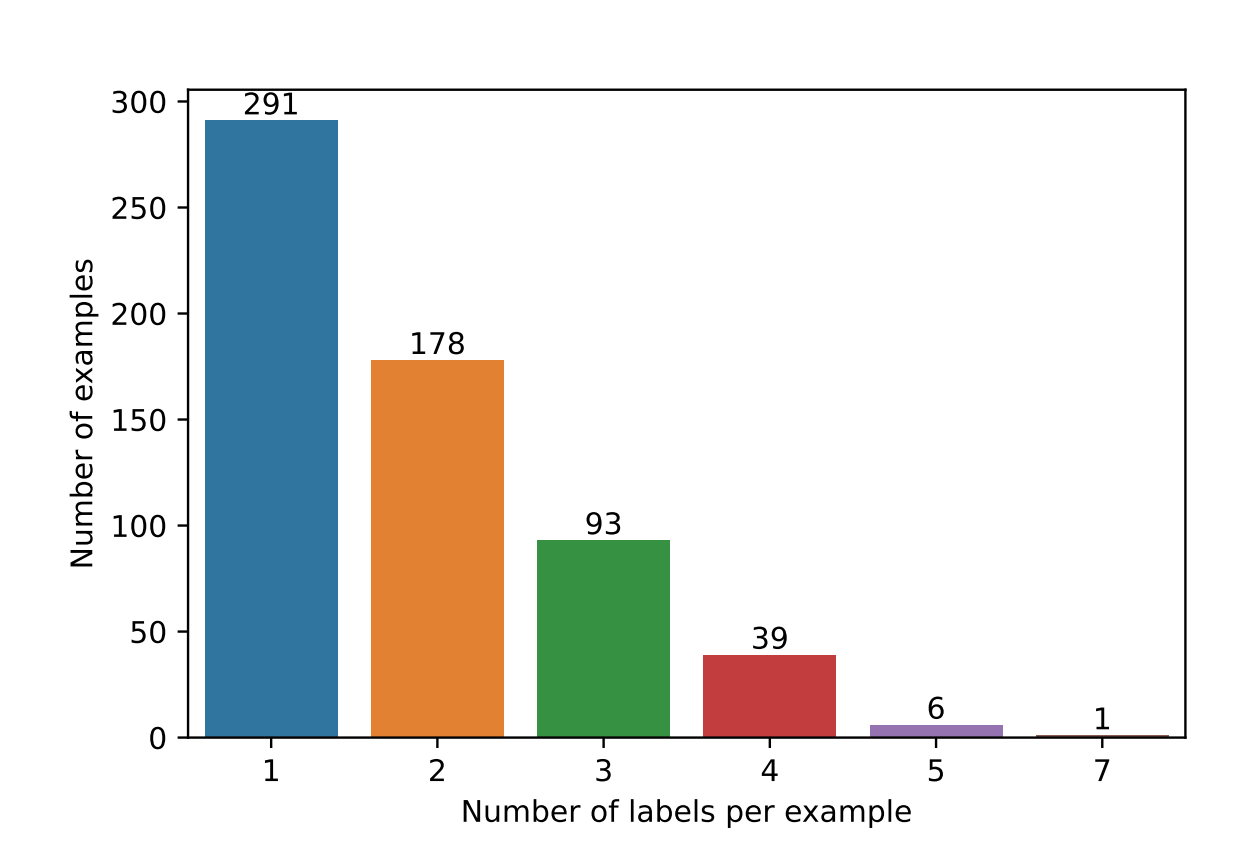

__The observations from the above visualization are:__


>1. The propaganda category (predicted value) is 33% and 22% for loaded language and name calling/labelling respictivaly. Therefore, like most of the NLP datasets this dataset is seems to be slightly imbalanced, but we're not sure (yet) if this imbalanced will be significant. We’ll come back to this in the modeling section.  

>2.  Less than 1% of tweets style were not written in MSA
(tweets index number 1 and 341)

>3. Most examples have one label per example as shown in second visualization. it is clear that number of examples having more than one label diminishes quickly, with only one example having 7 labels.

>4. Most frequent propaganda techniques combinations in Train set is loaded language followed by loaded language and name calling/labelling

In [ ]:

# Use the apply method to convert each row of the "labels" column to a string
df1["labels"] = df1["labels"].apply(lambda x: " ".join(x))

# Use the nunique method to get the number of unique values in the "labels" column
unique_labels = df1["labels"].nunique()

# Print the unique values in the "labels" column
print("Number of unique labels:", unique_labels)
print("Unique labels:", df1["labels"].unique())

Number of unique labels: 101
Unique labels: ['no technique' 'Smears Exaggeration/Minimisation'
 'Loaded Language Appeal to fear/prejudice Name calling/Labeling'
 'Slogans' 'Loaded Language Appeal to fear/prejudice'
 'Loaded Language Name calling/Labeling'
 'Loaded Language Appeal to fear/prejudice Exaggeration/Minimisation Name calling/Labeling'
 'Loaded Language'
 'Loaded Language Name calling/Labeling Appeal to fear/prejudice Exaggeration/Minimisation'
 'Loaded Language Repetition Name calling/Labeling'
 'Loaded Language Smears Exaggeration/Minimisation'
 'Doubt Loaded Language' 'Slogans Loaded Language Name calling/Labeling'
 'Doubt Loaded Language Name calling/Labeling' 'Loaded Language Smears'
 'Slogans Loaded Language Obfuscation, Intentional vagueness, Confusion Name calling/Labeling'
 'Name calling/Labeling' 'Loaded Language Smears Name calling/Labeling'
 'Loaded Language Obfuscation, Intentional vagueness, Confusion'
 'Loaded Language Name calling/Labeling Appeal to fear/preju

In [ ]:
df1.head(503)

,id,text,labels,tokens,column_char_count
0,1358824915483435008,"#بي_بي_سي_ترندينغ: النساء ""تثرثر كثيرا"" رئيس أولمبياد #طوكيو يتعرض لضغوط للاستقالة بعد تصريحه المثير للجدل https://t.co/Ywtth34LqF",[no technique],"[#بي_بي_سي_ترندينغ:, النساء, ""تثرثر, كثيرا"", رئيس, أولمبياد, #طوكيو, يتعرض, لضغوط, للاستقالة, بعد, تصريحه, المثير, للجدل, https://t.co/Ywtth34LqF]",130
1,1389927866356412416,"""ده مش معتقل ده أحسن من اللوكاندة"".. جدل وسخرية من زيارات تنظمها وزارة الداخلية للسجون #مصر https://t.co/VkkCrRjOCF","[Smears, Exaggeration/Minimisation]","[""ده, مش, معتقل, ده, أحسن, من, اللوكاندة"".., جدل, وسخرية, من, زيارات, تنظمها, وزارة, الداخلية, للسجون, #مصر, https://t.co/VkkCrRjOCF]",115
2,1364082975428677632,الرجل الذي كان من فراغ https://t.co/2bnHiRqGRQ,[no technique],"[الرجل, الذي, كان, من, فراغ, https://t.co/2bnHiRqGRQ]",46
3,1391667689656102912,RT @AJABreaking: عاجل | حركة حماس: ما يجري في المسجد الأقصى مجزرة حقيقية ستدفع سلطات الاحتلال الإسرائيلية ثمنها,"[Loaded Language, Appeal to fear/prejudice, Name calling/Labeling]","[RT, @AJABreaking:, عاجل, |, حركة, حماس:, ما, يجري, في, المسجد, الأقصى, مجزرة, حقيقية, ستدفع, سلطات, الاحتلال, الإسرائيلية, ثمنها]",111
4,1389360446440972288,"انطلاق أسبوع المرور العربي تحت شعار: ""الحوادث ليست بمصير بل إهمال وتقصير"".",[Slogans],"[انطلاق, أسبوع, المرور, العربي, تحت, شعار:, ""الحوادث, ليست, بمصير, بل, إهمال, وتقصير"".]",74
...,...,...,...,...,...
498,1319679682934177792,RT @ScreenMix: متاجر عديدة في الكويت تبدأ بإزالة المنتجات الفرنسية بعد تصريحات الرئيس الفرنسي إيمانويل ماكرون المسيئة للإسلام. https://t.co…,[Smears],"[RT, @ScreenMix:, متاجر, عديدة, في, الكويت, تبدأ, بإزالة, المنتجات, الفرنسية, بعد, تصريحات, الرئيس, الفرنسي, إيمانويل, ماكرون, المسيئة, للإسلام., https://t.co…]",140
499,1394708550304288768,رئيس المجموعة العربية: مجلس الأمن غير قادر حتى الآن على تبني وثيقة تعبر عن موقف موحد تجاه القمع الذي يعانيه الفلسطينيون,"[Loaded Language, Smears]","[رئيس, المجموعة, العربية:, مجلس, الأمن, غير, قادر, حتى, الآن, على, تبني, وثيقة, تعبر, عن, موقف, موحد, تجاه, القمع, الذي, يعانيه, الفلسطينيون]",119
500,866965157464952832,مقال رأي: النهضة ومنظومة بن علي وجهان لعملة واحدة https://t.co/e7sm9PJ1IE https://t.co/85GznjenCW,"[Smears, Doubt]","[مقال, رأي:, النهضة, ومنظومة, بن, علي, وجهان, لعملة, واحدة, https://t.co/e7sm9PJ1IE, https://t.co/85GznjenCW]",97
501,1388010230991134720,"من أفغانستان إلى العراق إلى ثورة يناير كيف زيفت ""سينرجي"" التاريخ بوصاية المخابرات العامة؟ https://t.co/MTAFoxBVhW https://t.co/aaINQrDi99","[Loaded Language, Smears]","[من, أفغانستان, إلى, العراق, إلى, ثورة, يناير, كيف, زيفت, ""سينرجي"", التاريخ, بوصاية, المخابرات, العامة؟, https://t.co/MTAFoxBVhW, https://t.co/aaINQrDi99]",137


In [ ]:
!pip3 install twarc

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 KB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.0/110.0 KB 11.6 MB/s eta 0:00:00
  Attempting uninstall: humanize
    Found existing installation: humanize 0.5.1
    Uninstalling humanize-0.5.1:
      Successfully uninstalled humanize-0.5.1
